# Tutorial 05 — Giải Thích Mô Hình Với SHAP (eXplainable AI)

> **Mục tiêu:** "Mở hộp đen" Random Forest — trả lời câu hỏi sống còn của kỹ sư: *"Mô hình dựa vào **dấu hiệu vật lý nào** để kết luận ổ lăn hỏng, và tôi có nên tin để **dừng máy** không?"*

---

## 🎯 Bạn sẽ học được gì?

| Kỹ năng | Giá trị thực tế |
|---|---|
| Trực giác **Shapley value** | Hiểu cách "chia công" cho từng đặc trưng |
| Đọc **Summary plot** | Biết đặc trưng nào quyết định từng loại lỗi |
| Đọc **Waterfall plot** (giá trị vật lý) | Giải thích *một ca cụ thể* → thuyết phục được kỹ sư |
| Nối SHAP → hành động bảo trì | Biến giải thích thành quyết định |

## 🔑 3 con số cần nhớ

| Khái niệm | Ý nghĩa |
|---|---|
| **Base value** $E[f(x)]$ | Xác suất "mặc định" khi chưa biết đặc trưng nào |
| **SHAP dương (+)** | Đặc trưng **ủng hộ** lớp đang xét (đẩy phải) |
| **SHAP âm (−)** | Đặc trưng **phản bác** lớp đang xét (kéo trái) — cũng rất quan trọng! |

> 📌 **Điểm cải tiến:** Notebook này chia tập **theo file** (chống rò rỉ) và **bỏ StandardScaler** cho RF, nên waterfall hiển thị **giá trị vật lý thật** (vd `kurtosis = 12`) thay vì z-score khó đọc.

---


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import os

SEED = 42
plt.rcParams.update({'figure.figsize': (10, 5), 'figure.dpi': 100, 'font.size': 12})
print("Thư viện đã sẵn sàng!")


Thư viện đã sẵn sàng!


## 1. Trực giác về giá trị Shapley (Shapley Value)

SHAP dựa trên lý thuyết trò chơi. Tưởng tượng:
- 3 kỹ sư (A, B, C) cùng làm dự án được thưởng 100 triệu.
- SHAP value = Số tiền chia công bằng cho mỗi người dựa trên đóng góp thực tế của họ (thử mọi tổ hợp A làm một mình, A+B, A+C, v.v.)

Trong Machine Learning:
- **Dự án** = Một dự đoán của mô hình (ví dụ: xác suất lỗi IR là 90%).
- **Kỹ sư** = Các đặc trưng (RMS, Kurtosis, Band Energy, ...).
- **Phần thưởng cơ bản (Base Value)** = Xác suất trung bình nếu không biết thông tin gì (ví dụ: 25%).
- **SHAP value** = "Kỹ sư" (feature) này đã đóng góp bao nhiêu % để kéo xác suất từ 25% lên 90% (hoặc giảm xuống).


## 2. Chuẩn bị dữ liệu & huấn luyện Random Forest

Ta cần một mô hình RF đã huấn luyện để giải thích. Hai lựa chọn thiết kế quan trọng:

| Lựa chọn | Vì sao |
|---|---|
| **Chia theo file** (`GroupShuffleSplit` trên `groups.csv`) | Giống Tutorial 04 — accuracy & giải thích phản ánh đúng dữ liệu *chưa từng thấy* |
| **Không dùng StandardScaler** | Cây quyết định **bất biến với phép co giãn** → accuracy gần như không đổi, nhưng SHAP hiển thị **giá trị gốc** (kurtosis, rms thật) thay vì z-score |

> 💡 Đây là chi tiết nhỏ nhưng **cực kỳ quan trọng cho XAI**: nếu waterfall ghi `kurtosis = -0.3 (z-score)`, kỹ sư không hành động được. Ghi `kurtosis = 12` thì kỹ sư hiểu ngay "có xung va chạm mạnh".


In [2]:
import os
from sklearn.model_selection import GroupShuffleSplit

# Load dữ liệu từ Tutorial 03 — cần CẢ groups.csv để chia theo file
need = ["X_features.csv", "y_labels.csv", "groups.csv"]
if not all(os.path.exists(p) for p in need):
    raise FileNotFoundError("Thiếu X_features/y_labels/groups.csv. Hãy chạy Tutorial 03 trước!")

X_features = pd.read_csv("X_features.csv")
y_labels = pd.read_csv("y_labels.csv").iloc[:, 0]
groups = pd.read_csv("groups.csv").iloc[:, 0]

le = LabelEncoder()
y_enc = le.fit_transform(y_labels)
cls_names = list(le.classes_)

# Chia THEO FILE (chống rò rỉ) — nhất quán với Tutorial 04
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=SEED)
train_idx, test_idx = next(gss.split(X_features, y_enc, groups=groups))
X_train = X_features.iloc[train_idx].reset_index(drop=True)
X_test  = X_features.iloc[test_idx].reset_index(drop=True)
y_train = y_enc[train_idx]
y_test  = y_enc[test_idx]

# ⚠️ Random Forest KHÔNG cần StandardScaler (cây bất biến với phép co giãn).
# Bỏ scaler -> SHAP waterfall hiển thị GIÁ TRỊ VẬT LÝ thật
# (vd kurtosis = 12, không phải z-score = 1.5) -> kỹ sư đọc được ngay.
rf_model = RandomForestClassifier(n_estimators=200, max_depth=None,
                                  random_state=SEED, n_jobs=-1)
rf_model.fit(X_train, y_train)

X_test_df = X_test    # giữ tên biến cho các cell sau; ĐÂY LÀ GIÁ TRỊ GỐC
print(f"Train: {len(X_train)} | Test: {len(X_test)} segment (chia theo file)")
print(f"Test Accuracy: {rf_model.score(X_test, y_test):.2%}")


Train: 16424 | Test: 6170 segment (chia theo file)
Test Accuracy: 78.62%


## 3. Tính toán SHAP values

Dùng `shap.TreeExplainer` (cực nhanh và tối ưu cho Random Forest / XGBoost).


In [3]:
print("Đang tính SHAP values...")
explainer = shap.TreeExplainer(rf_model)

# ⚠️ Chia theo file -> X_test xếp theo từng file (cùng lớp đứng liền nhau).
# Lấy 300 mẫu ĐẦU sẽ chỉ thuộc 1–2 lớp. Phải lấy mẫu NGẪU NHIÊN để đủ 4 lớp.
n_explain = min(300, len(X_test_df))
rng = np.random.RandomState(SEED)
explain_sel = rng.permutation(len(X_test_df))[:n_explain]
X_exp = X_test_df.iloc[explain_sel].reset_index(drop=True)   # subset giải thích (GIÁ TRỊ GỐC)
y_exp = y_test[explain_sel]

shap_values_raw = explainer.shap_values(X_exp)

# Tương thích SHAP cũ (list) lẫn mới >=0.42 (mảng 3D: mẫu x đặc trưng x lớp)
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw
else:
    shap_values = [np.array(shap_values_raw)[:, :, c] for c in range(shap_values_raw.shape[2])]

print(f"✅ Xong! Đã tính SHAP cho {len(shap_values)} lớp.")
print(f"Kích thước mỗi lớp: {shap_values[0].shape} (số mẫu x số đặc trưng)")
print(f"Phân bố lớp trong subset: {dict(zip(*np.unique(le.inverse_transform(y_exp), return_counts=True)))}")


Đang tính SHAP values...


✅ Xong! Đã tính SHAP cho 4 lớp.
Kích thước mỗi lớp: (300, 19) (số mẫu x số đặc trưng)
Phân bố lớp trong subset: {'B': np.int64(75), 'IR': np.int64(109), 'Normal': np.int64(9), 'OR': np.int64(107)}


## 4. SHAP Summary Plot – "Đặc trưng nào quyết định loại lỗi nào?"

Đây là biểu đồ quan trọng nhất của SHAP.

**Cách đọc:**
- Mỗi **chấm** = 1 mẫu (trong 300 mẫu đã test).
- **Trục dọc (Y)** = Các đặc trưng sắp xếp theo độ quan trọng.
- **Trục ngang (X)** = SHAP value. Nếu > 0: Đặc trưng này làm TĂNG xác suất của lớp đang xét.
- **Màu sắc** = Giá trị thực của đặc trưng (Đỏ = Cao, Xanh = Thấp).


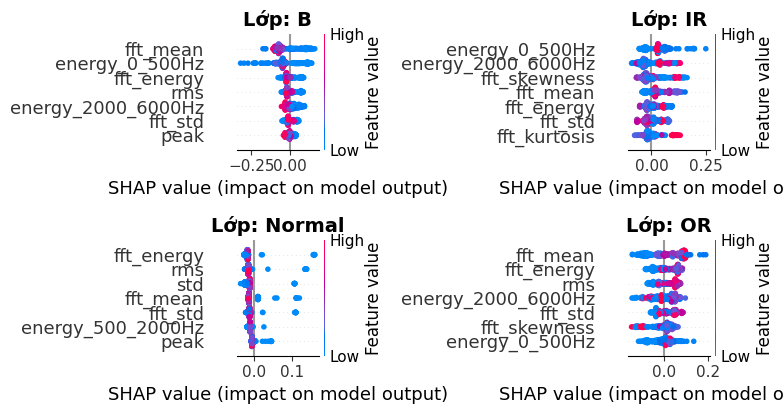


💡 VÍ DỤ CÁCH ĐỌC (Lớp IR - Rãnh trong):
- Xem dòng 'rms': các chấm ĐỎ (rms cao) nằm bên PHẢI (SHAP > 0)
  -> rms cao thì xác suất lỗi rãnh trong TĂNG.
- Chấm XANH (rms thấp) nằm bên TRÁI (SHAP < 0) -> làm GIẢM xác suất IR.


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, cls in enumerate(cls_names):
    plt.sca(axes[idx])
    shap.summary_plot(shap_values[idx], X_exp, show=False, max_display=7)
    plt.title(f'Lớp: {cls}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 VÍ DỤ CÁCH ĐỌC (Lớp IR - Rãnh trong):")
print("- Xem dòng 'rms': các chấm ĐỎ (rms cao) nằm bên PHẢI (SHAP > 0)")
print("  -> rms cao thì xác suất lỗi rãnh trong TĂNG.")
print("- Chấm XANH (rms thấp) nằm bên TRÁI (SHAP < 0) -> làm GIẢM xác suất IR.")


## 5. SHAP Waterfall Plot — Giải phẫu **một** quyết định cụ thể

Summary plot = góc nhìn **vĩ mô** (toàn bộ test). Waterfall = góc nhìn **vi mô**: vì sao mô hình kết luận *đúng mẫu này*?

> *"Tại sao hệ thống báo vòng bi #123 lỗi rãnh ngoài (OR) lúc 10h sáng nay?"*

**Cách đọc waterfall:**

| Thành phần | Ý nghĩa |
|---|---|
| $E[f(x)]$ (dưới cùng) | Điểm xuất phát — xác suất gốc khi chưa biết đặc trưng |
| Thanh **đỏ →** | Đặc trưng **đẩy** về phía lớp OR (bằng chứng ủng hộ) |
| Thanh **xanh ←** | Đặc trưng **kéo** ra xa lớp OR (bằng chứng phản bác) |
| Số bên cạnh tên feature | **Giá trị vật lý thật** (vd `kurtosis = 12.3`) — đọc & hành động được ngay |
| $f(x)$ (trên cùng) | Xác suất cuối = base + tổng mọi SHAP |

> 💡 **Biến waterfall thành câu chuyện:** *"env/kurtosis cao + năng lượng dải tần lỗi cao → đẩy mạnh về OR; chỉ crest hơi thấp phản bác nhẹ → kết luận OR với xác suất 0.9x."* Đây chính là cách thuyết phục kỹ sư hiện trường.


Mẫu (index trong subset) = 1 | Nhãn thật: OR | Dự đoán: OR


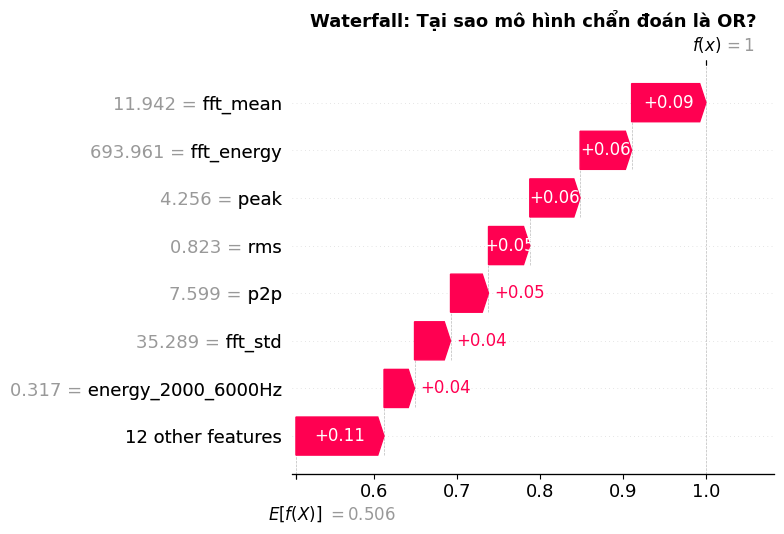


💡 CÁCH ĐỌC:
1. Khởi điểm E[f(x)] = 0.506  — xác suất gốc trung bình của lớp OR.
2. Thanh ĐỎ đẩy sang PHẢI  -> tăng xác suất bị OR.
3. Thanh XANH kéo sang TRÁI -> giảm xác suất bị OR.
4. Kết quả cuối f(x) = 1.000  (xác suất mô hình chốt lại).
   Giá trị feature hiển thị là GIÁ TRỊ VẬT LÝ THẬT (đã bỏ scaler).


In [5]:
# Chọn 1 mẫu thuộc lớp lỗi rãnh ngoài (OR) trong subset đã tính SHAP
or_idx = cls_names.index('OR')
matches = np.where(y_exp == or_idx)[0]
if len(matches) == 0:
    raise ValueError("Subset giải thích không có mẫu OR — hãy tăng n_explain ở cell trên.")
sample_idx = matches[0]

# Dự đoán trên GIÁ TRỊ GỐC (không scale) — nhất quán với cách train
pred = cls_names[rf_model.predict(X_exp.iloc[[sample_idx]])[0]]
print(f"Mẫu (index trong subset) = {sample_idx} | Nhãn thật: OR | Dự đoán: {pred}")

# expected_value có thể là scalar hoặc mảng theo lớp -> xử lý an toàn
ev = explainer.expected_value
base_val = ev[or_idx] if hasattr(ev, '__len__') else ev

# data = giá trị VẬT LÝ gốc (kurtosis=12...) nhờ đã bỏ scaler
exp = shap.Explanation(
    values=shap_values[or_idx][sample_idx],          # (19,) cho lớp OR
    base_values=base_val,
    data=X_exp.iloc[sample_idx].values,
    feature_names=list(X_features.columns)
)

shap.plots.waterfall(exp, max_display=8, show=False)   # API mới (shap >= 0.41)
plt.title('Waterfall: Tại sao mô hình chẩn đoán là OR?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 CÁCH ĐỌC:")
print(f"1. Khởi điểm E[f(x)] = {base_val:.3f}  — xác suất gốc trung bình của lớp OR.")
print("2. Thanh ĐỎ đẩy sang PHẢI  -> tăng xác suất bị OR.")
print("3. Thanh XANH kéo sang TRÁI -> giảm xác suất bị OR.")
print(f"4. Kết quả cuối f(x) = {exp.values.sum() + base_val:.3f}  (xác suất mô hình chốt lại).")
print("   Giá trị feature hiển thị là GIÁ TRỊ VẬT LÝ THẬT (đã bỏ scaler).")


## 6. Từ SHAP đến Hành động bảo trì

| Kết quả SHAP | Tình trạng vật lý suy ra | Khuyến nghị hành động |
|---|---|---|
| Báo IR/OR + **rms cao (SHAP>0)** + crest/peak ~ bình thường | Rung tổng thể tăng nhưng *chưa* có xung sắc nét → có thể lỏng trục, mòn đều, cọ xát | Bảo dưỡng định kỳ gần nhất; siết cơ cấu; kiểm tra bôi trơn |
| Báo IR/OR + **kurtosis cao (SHAP>0)** + **peak cao** | Xung va chạm chu kỳ sắc nét → vết rỗ/nứt đã hình thành trên rãnh | 🟡 **Báo động vàng** — lên kế hoạch thay ổ lăn sớm |
| Báo lỗi + **năng lượng dải tần (`energy_*`) SHAP rất cao** | Năng lượng dồn vào dải chứa tần số lỗi/cộng hưởng → chẩn đoán độ tin cậy cao | 🔴 **Xác nhận hỏng** — chuẩn bị phụ tùng, thay trong lần dừng máy gần nhất |
| Đặc trưng "lạ" (vd `mean`) bỗng quan trọng | Có thể không phải lỗi ổ lăn (lệch trục → 2×, mất cân bằng → 1×, lỏng bu-lông → nhiều bội) | Kiểm tra lệch trục, mất cân bằng, lỏng lẻo trước khi thay ổ lăn |

> ⚠️ **Nhắc lại:** Tần số lỗi cơ bản (BPFO≈107, BPFI≈162 Hz; lỗi bi ≈ 2·BSF ≈ 141 Hz, BSF cơ bản ≈ 70.6 Hz) nằm trong dải `0_500Hz`; `energy_500_2000Hz`/`2000_6000Hz` phản ánh **harmonics & cộng hưởng kết cấu** do xung kích thích, không phải tần số lỗi cơ bản.

---

## 📝 Tóm tắt & Key Takeaways

✅ **Bạn đã học:**
1. SHAP **phân bổ "công lao"** cho từng đặc trưng → giải thích quyết định mô hình.
2. **Summary plot** (vĩ mô) vs **Waterfall plot** (vi mô, 1 ca cụ thể).
3. **SHAP âm cũng quan trọng** — nó là bằng chứng *phản bác*, giúp soi mô hình.
4. Hiển thị **giá trị vật lý** (không scale) là điều kiện để kỹ sư hành động được.

🎯 **Thông điệp:** SHAP không thay kinh nghiệm kỹ sư — nó là "cố vấn AI minh bạch". Kỹ sư vẫn ra quyết định cuối, nhưng nay có lý do vật lý rõ ràng.

---

## 🏋️ Bài tập

1. Sửa mục 5 để vẽ waterfall cho 1 mẫu **Normal** — đặc trưng nào "thuyết phục" mô hình rằng nó bình thường?
2. Dùng `shap.KernelExplainer(svm.predict_proba, background)` cho SVM ở Tutorial 04 (⚠️ SVM phải `probability=True`). So tốc độ với TreeExplainer — chậm hơn bao nhiêu lần?
3. Tìm 1 mẫu mô hình **dự đoán sai** → đọc waterfall: đặc trưng nào "đánh lừa" mô hình?

---
*Tutorial 05/05 — Khóa đào tạo "Ứng dụng ML trong chẩn đoán thiết bị quay"*
